In [19]:
import json
import os
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
HUMAN_RATING_DIR = "human_rating"
LLM_RATING_DIR = "llm_rating"

In [20]:
def load_ground_truth_from_llm_files(results_dir):
    """Load ground truth from LLM rating files. Returns dict mapping title -> ground_truth."""
    ground_truth = {}
    for result_file in sorted(os.listdir(results_dir)):
        if result_file.endswith('.jsonl'):
            file_path = os.path.join(results_dir, result_file)
            with open(file_path, "r", encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        data = json.loads(line)
                        title = data.get("title", "")
                        gt = data.get("ground_truth", False)
                        # Use title as key, if duplicate titles exist, last one wins
                        ground_truth[title] = gt
    return ground_truth

def load_llm_predictions_and_ground_truth(results_dir):
    """Load LLM predictions and ground truth from LLM rating files."""
    predictions = []
    ground_truths = []
    matched = 0
    unmatched = []
    
    for result_file in sorted(os.listdir(results_dir)):
        if result_file.endswith('.jsonl'):
            file_path = os.path.join(results_dir, result_file)
            with open(file_path, "r", encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        data = json.loads(line)
                        title = data.get("title", "")
                        prediction = data.get("keep", False)
                        gt = data.get("ground_truth", False)
                        
                        if title:  # If title exists, include it
                            predictions.append(prediction)
                            ground_truths.append(gt)
                            matched += 1
                        else:
                            unmatched.append("No title")
    
    return predictions, ground_truths, matched, unmatched

def load_predictions_from_file(file_path, ground_truth_dict):
    """Load predictions from a single JSONL file and match with ground truth."""
    predictions = []
    ground_truths = []
    matched = 0
    unmatched = []
    
    with open(file_path, "r", encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data = json.loads(line)
                title = data.get("title", "")
                prediction = data.get("keep", False)
                
                if title in ground_truth_dict:
                    predictions.append(prediction)
                    ground_truths.append(ground_truth_dict[title])
                    matched += 1
                else:
                    unmatched.append(title)
    
    return predictions, ground_truths, matched, unmatched

def calculate_metrics(y_true, y_pred):
    """Calculate all classification metrics."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics["confusion_matrix"] = cm
    
    # Extract TP, TN, FP, FN from confusion matrix
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics["true_positives"] = tp
        metrics["true_negatives"] = tn
        metrics["false_positives"] = fp
        metrics["false_negatives"] = fn
    else:
        metrics["true_positives"] = int(cm[1, 1]) if cm.shape == (2, 2) else 0
        metrics["true_negatives"] = int(cm[0, 0]) if cm.shape == (2, 2) else 0
        metrics["false_positives"] = int(cm[0, 1]) if cm.shape == (2, 2) else 0
        metrics["false_negatives"] = int(cm[1, 0]) if cm.shape == (2, 2) else 0
    
    return metrics

def plot_confusion_matrix(cm, title, ax=None):
    """Plot confusion matrix."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Keep', 'Keep'],
                yticklabels=['Not Keep', 'Keep'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    
    return ax


In [21]:
# Load ground truth from LLM rating files (ground_truth field)
print("Loading ground truth from LLM rating files...")
title_gt = load_ground_truth_from_llm_files(os.path.join(LLM_RATING_DIR, "title"))
content_gt = load_ground_truth_from_llm_files(os.path.join(LLM_RATING_DIR, "content"))

print(f"Loaded {len(title_gt)} title ground truth entries")
print(f"Loaded {len(content_gt)} content ground truth entries")


Loading ground truth from LLM rating files...
Loaded 183 title ground truth entries
Loaded 125 content ground truth entries


In [22]:
# Calculate LLM vs Ground Truth metrics
# Load LLM predictions and ground truth directly from LLM rating files
print("\n" + "="*80)
print("LLM RATING vs GROUND TRUTH")
print("="*80)

# Title screening - LLM
print("\n--- Title Screening (LLM) ---")
llm_title_pred, llm_title_gt, llm_title_matched, llm_title_unmatched = load_llm_predictions_and_ground_truth(
    os.path.join(LLM_RATING_DIR, "title")
)
print(f"Loaded {llm_title_matched} articles")

if llm_title_pred:
    llm_title_metrics = calculate_metrics(llm_title_gt, llm_title_pred)
    llm_title_metrics["total_samples"] = len(llm_title_pred)
    llm_title_metrics["stage"] = "Title"
    llm_title_metrics["rater"] = "LLM"
    
    print(f"\nMetrics:")
    print(f"  Accuracy:  {llm_title_metrics['accuracy']:.4f}")
    print(f"  Precision: {llm_title_metrics['precision']:.4f}")
    print(f"  Recall:    {llm_title_metrics['recall']:.4f}")
    print(f"  F1 Score:  {llm_title_metrics['f1_score']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {llm_title_metrics['true_positives']}, TN: {llm_title_metrics['true_negatives']}")
    print(f"  FP: {llm_title_metrics['false_positives']}, FN: {llm_title_metrics['false_negatives']}")

# Content screening - LLM
print("\n--- Content Screening (LLM) ---")
llm_content_pred, llm_content_gt, llm_content_matched, llm_content_unmatched = load_llm_predictions_and_ground_truth(
    os.path.join(LLM_RATING_DIR, "content")
)
print(f"Loaded {llm_content_matched} articles")

if llm_content_pred:
    llm_content_metrics = calculate_metrics(llm_content_gt, llm_content_pred)
    llm_content_metrics["total_samples"] = len(llm_content_pred)
    llm_content_metrics["stage"] = "Content"
    llm_content_metrics["rater"] = "LLM"
    
    print(f"\nMetrics:")
    print(f"  Accuracy:  {llm_content_metrics['accuracy']:.4f}")
    print(f"  Precision: {llm_content_metrics['precision']:.4f}")
    print(f"  Recall:    {llm_content_metrics['recall']:.4f}")
    print(f"  F1 Score:  {llm_content_metrics['f1_score']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {llm_content_metrics['true_positives']}, TN: {llm_content_metrics['true_negatives']}")
    print(f"  FP: {llm_content_metrics['false_positives']}, FN: {llm_content_metrics['false_negatives']}")



LLM RATING vs GROUND TRUTH

--- Title Screening (LLM) ---
Loaded 183 articles

Metrics:
  Accuracy:  0.8415
  Precision: 0.9098
  Recall:    0.8605
  F1 Score:  0.8845

Confusion Matrix:
  TP: 111, TN: 43
  FP: 11, FN: 18

--- Content Screening (LLM) ---
Loaded 125 articles

Metrics:
  Accuracy:  0.8800
  Precision: 0.9417
  Recall:    0.9151
  F1 Score:  0.9282

Confusion Matrix:
  TP: 97, TN: 13
  FP: 6, FN: 9


In [24]:
# Calculate Human vs Ground Truth metrics
# Human ratings are in the filtered files (title_filtered.jsonl and content_filtered.jsonl)
# Ground truth is from LLM rating files (already loaded in title_gt and content_gt)
print("\n" + "="*80)
print("HUMAN RATING vs GROUND TRUTH")
print("="*80)

# Title screening - Human (load from filtered file which has the keep field)
print("\n--- Title Screening (Human) ---")
human_title_pred, human_title_gt, human_title_matched, human_title_unmatched = load_predictions_from_file(
    os.path.join(HUMAN_RATING_DIR, "title_filtered.jsonl"), title_gt
)
print(f"Matched {human_title_matched} articles")
if human_title_unmatched:
    print(f"Warning: {len(human_title_unmatched)} articles could not be matched")

if human_title_pred:
    human_title_metrics = calculate_metrics(human_title_gt, human_title_pred)
    human_title_metrics["total_samples"] = len(human_title_pred)
    human_title_metrics["stage"] = "Title"
    human_title_metrics["rater"] = "Human"
    
    print(f"\nMetrics:")
    print(f"  Accuracy:  {human_title_metrics['accuracy']:.4f}")
    print(f"  Precision: {human_title_metrics['precision']:.4f}")
    print(f"  Recall:    {human_title_metrics['recall']:.4f}")
    print(f"  F1 Score:  {human_title_metrics['f1_score']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {human_title_metrics['true_positives']}, TN: {human_title_metrics['true_negatives']}")
    print(f"  FP: {human_title_metrics['false_positives']}, FN: {human_title_metrics['false_negatives']}")

# Content screening - Human (load from filtered file which has the keep field)
print("\n--- Content Screening (Human) ---")
human_content_pred, human_content_gt, human_content_matched, human_content_unmatched = load_predictions_from_file(
    os.path.join(HUMAN_RATING_DIR, "content_filtered.jsonl"), content_gt
)
print(f"Matched {human_content_matched} articles")
if human_content_unmatched:
    print(f"Warning: {len(human_content_unmatched)} articles could not be matched")

if human_content_pred:
    human_content_metrics = calculate_metrics(human_content_gt, human_content_pred)
    human_content_metrics["total_samples"] = len(human_content_pred)
    human_content_metrics["stage"] = "Content"
    human_content_metrics["rater"] = "Human"
    
    print(f"\nMetrics:")
    print(f"  Accuracy:  {human_content_metrics['accuracy']:.4f}")
    print(f"  Precision: {human_content_metrics['precision']:.4f}")
    print(f"  Recall:    {human_content_metrics['recall']:.4f}")
    print(f"  F1 Score:  {human_content_metrics['f1_score']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {human_content_metrics['true_positives']}, TN: {human_content_metrics['true_negatives']}")
    print(f"  FP: {human_content_metrics['false_positives']}, FN: {human_content_metrics['false_negatives']}")



HUMAN RATING vs GROUND TRUTH

--- Title Screening (Human) ---
Matched 183 articles

Metrics:
  Accuracy:  0.8361
  Precision: 0.8613
  Recall:    0.9147
  F1 Score:  0.8872

Confusion Matrix:
  TP: 118, TN: 35
  FP: 19, FN: 11

--- Content Screening (Human) ---
Matched 121 articles

Metrics:
  Accuracy:  0.8760
  Precision: 0.9314
  Recall:    0.9223
  F1 Score:  0.9268

Confusion Matrix:
  TP: 95, TN: 11
  FP: 7, FN: 8


In [25]:
# Create summary table
summary_data = []

if llm_title_pred:
    summary_data.append({
        'Rater': 'LLM',
        'Stage': 'Title',
        'Total Samples': llm_title_metrics['total_samples'],
        'Accuracy': llm_title_metrics['accuracy'],
        'Precision': llm_title_metrics['precision'],
        'Recall': llm_title_metrics['recall'],
        'F1 Score': llm_title_metrics['f1_score'],
        'TP': llm_title_metrics['true_positives'],
        'TN': llm_title_metrics['true_negatives'],
        'FP': llm_title_metrics['false_positives'],
        'FN': llm_title_metrics['false_negatives']
    })

if llm_content_pred:
    summary_data.append({
        'Rater': 'LLM',
        'Stage': 'Content',
        'Total Samples': llm_content_metrics['total_samples'],
        'Accuracy': llm_content_metrics['accuracy'],
        'Precision': llm_content_metrics['precision'],
        'Recall': llm_content_metrics['recall'],
        'F1 Score': llm_content_metrics['f1_score'],
        'TP': llm_content_metrics['true_positives'],
        'TN': llm_content_metrics['true_negatives'],
        'FP': llm_content_metrics['false_positives'],
        'FN': llm_content_metrics['false_negatives']
    })

if human_title_pred:
    summary_data.append({
        'Rater': 'Human',
        'Stage': 'Title',
        'Total Samples': human_title_metrics['total_samples'],
        'Accuracy': human_title_metrics['accuracy'],
        'Precision': human_title_metrics['precision'],
        'Recall': human_title_metrics['recall'],
        'F1 Score': human_title_metrics['f1_score'],
        'TP': human_title_metrics['true_positives'],
        'TN': human_title_metrics['true_negatives'],
        'FP': human_title_metrics['false_positives'],
        'FN': human_title_metrics['false_negatives']
    })

if human_content_pred:
    summary_data.append({
        'Rater': 'Human',
        'Stage': 'Content',
        'Total Samples': human_content_metrics['total_samples'],
        'Accuracy': human_content_metrics['accuracy'],
        'Precision': human_content_metrics['precision'],
        'Recall': human_content_metrics['recall'],
        'F1 Score': human_content_metrics['f1_score'],
        'TP': human_content_metrics['true_positives'],
        'TN': human_content_metrics['true_negatives'],
        'FP': human_content_metrics['false_positives'],
        'FN': human_content_metrics['false_negatives']
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))



SUMMARY TABLE
Rater   Stage  Total Samples  Accuracy  Precision   Recall  F1 Score  TP  TN  FP  FN
  LLM   Title            183  0.841530   0.909836 0.860465  0.884462 111  43  11  18
  LLM Content            125  0.880000   0.941748 0.915094  0.928230  97  13   6   9
Human   Title            183  0.836066   0.861314 0.914729  0.887218 118  35  19  11
Human Content            121  0.876033   0.931373 0.922330  0.926829  95  11   7   8


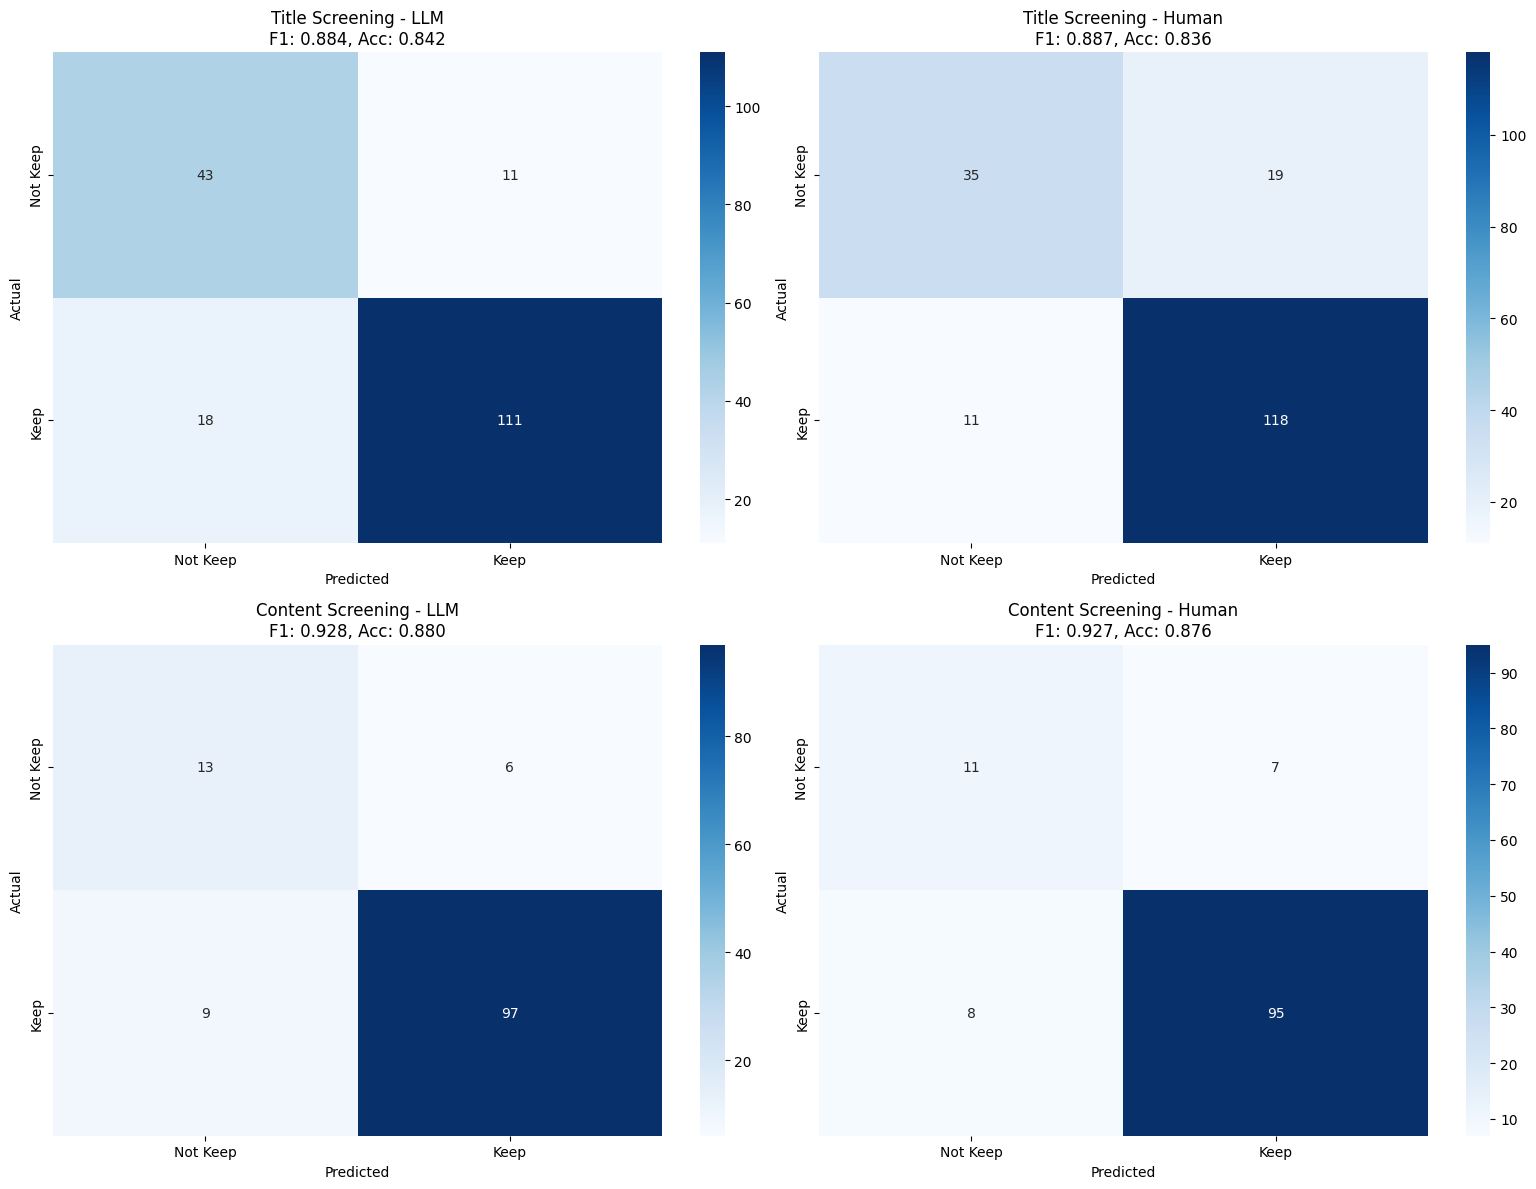

In [26]:
# Visualize confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Title - LLM
if llm_title_pred:
    plot_confusion_matrix(llm_title_metrics['confusion_matrix'], 
                         f"Title Screening - LLM\n"
                         f"F1: {llm_title_metrics['f1_score']:.3f}, "
                         f"Acc: {llm_title_metrics['accuracy']:.3f}",
                         ax=axes[0, 0])

# Title - Human
if human_title_pred:
    plot_confusion_matrix(human_title_metrics['confusion_matrix'], 
                         f"Title Screening - Human\n"
                         f"F1: {human_title_metrics['f1_score']:.3f}, "
                         f"Acc: {human_title_metrics['accuracy']:.3f}",
                         ax=axes[0, 1])

# Content - LLM
if llm_content_pred:
    plot_confusion_matrix(llm_content_metrics['confusion_matrix'], 
                         f"Content Screening - LLM\n"
                         f"F1: {llm_content_metrics['f1_score']:.3f}, "
                         f"Acc: {llm_content_metrics['accuracy']:.3f}",
                         ax=axes[1, 0])

# Content - Human
if human_content_pred:
    plot_confusion_matrix(human_content_metrics['confusion_matrix'], 
                         f"Content Screening - Human\n"
                         f"F1: {human_content_metrics['f1_score']:.3f}, "
                         f"Acc: {human_content_metrics['accuracy']:.3f}",
                         ax=axes[1, 1])

plt.tight_layout()
plt.show()


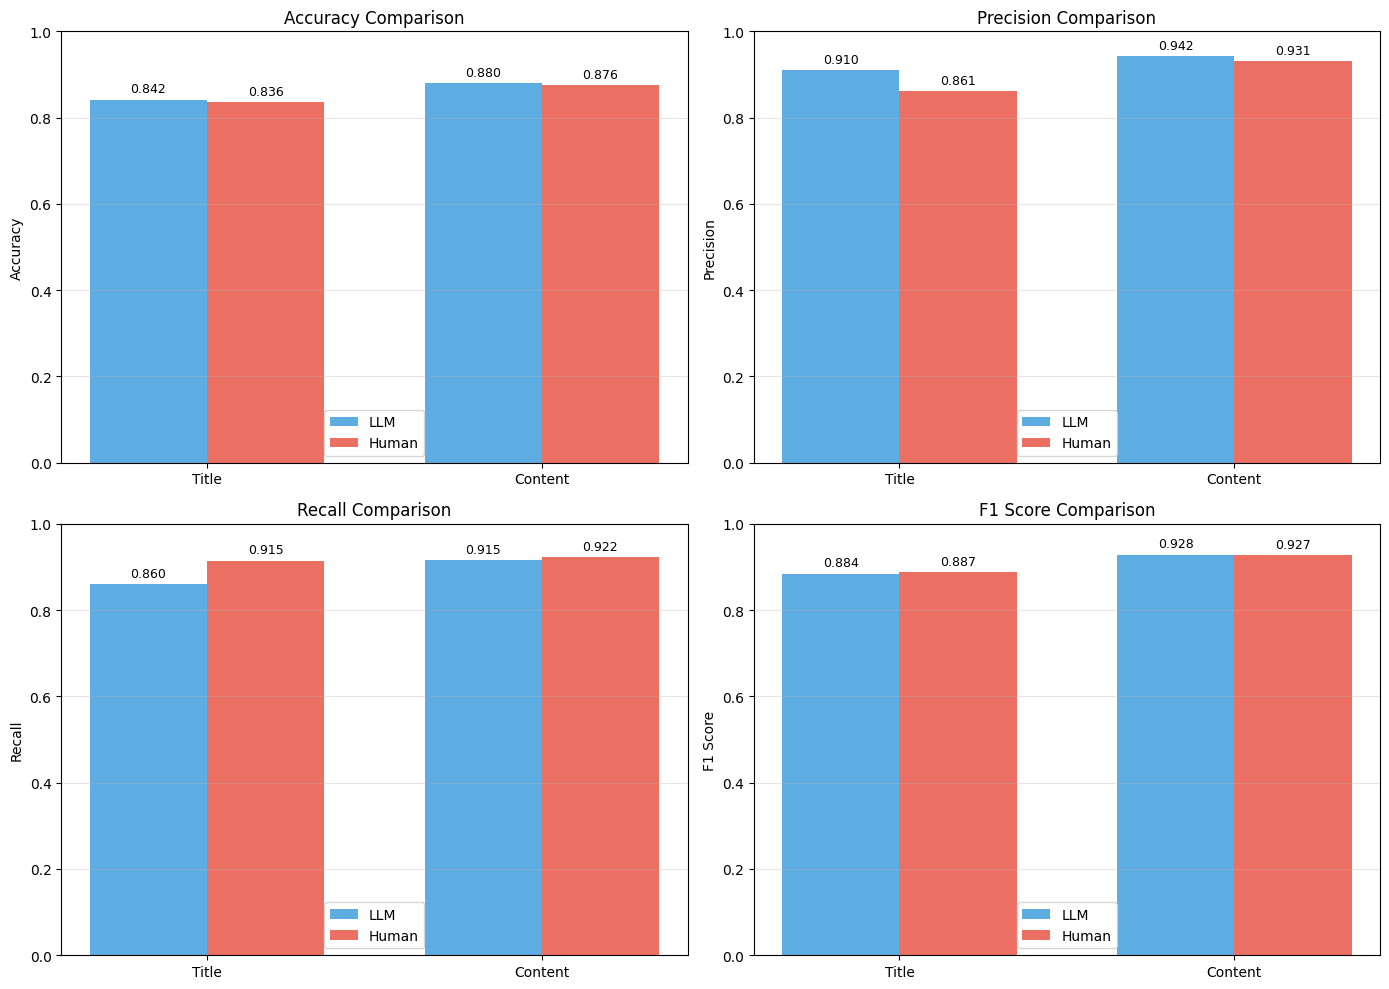

In [27]:
# Compare metrics between LLM and Human
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    
    stages = []
    llm_values = []
    human_values = []
    
    if llm_title_pred:
        stages.append('Title')
        llm_values.append(llm_title_metrics[metric])
        if human_title_pred:
            human_values.append(human_title_metrics[metric])
        else:
            human_values.append(0)
    
    if llm_content_pred:
        stages.append('Content')
        llm_values.append(llm_content_metrics[metric])
        if human_content_pred:
            human_values.append(human_content_metrics[metric])
        else:
            human_values.append(0)
    
    x = np.arange(len(stages))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, llm_values, width, label='LLM', alpha=0.8, color='#3498db')
    bars2 = ax.bar(x + width/2, human_values, width, label='Human', alpha=0.8, color='#e74c3c')
    
    ax.set_ylabel(label)
    ax.set_title(f'{label} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(stages)
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
